In [1]:
# 1️⃣ Import Libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
# 2️⃣ Load Dataset
df = pd.read_csv('/content/mobile_price_classification.csv')
print(df.head)

<bound method NDFrame.head of       battery_power  bluetooth  clock_speed  dual_sim  front_cam  4G  \
0               842          0          2.2         0          1   0   
1              1021          1          0.5         1          0   1   
2               563          1          0.5         1          2   1   
3               615          1          2.5         0          0   0   
4              1821          1          1.2         0         13   1   
...             ...        ...          ...       ...        ...  ..   
1995            794          1          0.5         1          0   1   
1996           1965          1          2.6         1          0   0   
1997           1911          0          0.9         1          1   1   
1998           1512          0          0.9         0          4   1   
1999            510          1          2.0         1          5   1   

      int_memory  m_dep  mobile_wt  n_cores  ...  px_height  px_width   ram  \
0              7    0.6   

In [3]:
df.columns

Index(['battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_cam',
       '4G', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'primary_camera',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [4]:
num_features = df.select_dtypes(include=['int64', 'float64']).columns
cat_features = df.select_dtypes(include=['object']).columns


print(num_features)
print( cat_features)

Index(['battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_cam',
       '4G', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'primary_camera',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')
Index([], dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   battery_power   2000 non-null   int64  
 1   bluetooth       2000 non-null   int64  
 2   clock_speed     2000 non-null   float64
 3   dual_sim        2000 non-null   int64  
 4   front_cam       2000 non-null   int64  
 5   4G              2000 non-null   int64  
 6   int_memory      2000 non-null   int64  
 7   m_dep           2000 non-null   float64
 8   mobile_wt       2000 non-null   int64  
 9   n_cores         2000 non-null   int64  
 10  primary_camera  2000 non-null   int64  
 11  px_height       2000 non-null   int64  
 12  px_width        2000 non-null   int64  
 13  ram             2000 non-null   int64  
 14  sc_h            2000 non-null   int64  
 15  sc_w            2000 non-null   int64  
 16  talk_time       2000 non-null   int64  
 17  three_g         2000 non-null   i

In [6]:

#Separate Feature Types
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print(numeric_cols)
print(cat_cols)

Index(['battery_power', 'bluetooth', 'clock_speed', 'dual_sim', 'front_cam',
       '4G', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'primary_camera',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')
Index([], dtype='object')


In [7]:
X = df.drop("price_range", axis=1)
y = df["price_range"]

In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# 6️⃣ Build Updated ANN Model
model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use 'sparse' because y is integers
    metrics=['accuracy']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 508 (1.98 KB)

 Trainable params: 508 (1.98 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.2815 - loss: 1.4777 - val_accuracy: 0.3000 - val_loss: 1.3337
Epoch 2/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3275 - loss: 1.3069 - val_accuracy: 0.4094 - val_loss: 1.2296
Epoch 3/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4335 - loss: 1.2063 - val_accuracy: 0.4594 - val_loss: 1.1539
Epoch 4/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4785 - loss: 1.1385 - val_accuracy: 0.5281 - val_loss: 1.0738
Epoch 5/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5593 - loss: 1.0304 - val_accuracy: 0.5719 - val_loss: 0.9966
Epoch 6/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5877 - loss: 0.9476 - val_accuracy: 0.6062 - val_loss: 0.9161
Epoch 7/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6247 - loss: 0.8863 - val_accuracy: 0.6562 - val_loss: 0.8412
Epoch 8/30
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6842 - loss: 0.8022 - val_accuracy: 0.6938 - val_loss:

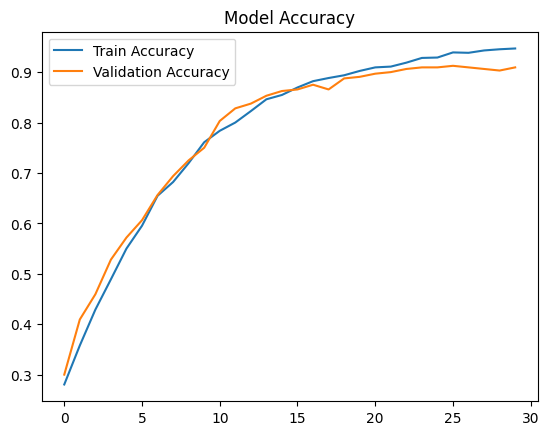

In [11]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy') #line graph
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') #line graph
plt.legend()
plt.title("Model Accuracy")
plt.show()

In [12]:
# Updated prediction logic
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1) # Pick the class with the highest score

print(classification_report(y_test, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       105
           1       0.90      0.93      0.92        91
           2       0.91      0.90      0.91        92
           3       0.95      0.94      0.95       112

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400



In [13]:
# 1️ Generate Predictions on  existing X_test
# We use 'model' and np.argmax because our model outputs 4 probabilities
y_pred_probs = model.predict(X_test)
prediction_test = np.argmax(y_pred_probs, axis=1)

# 2️ Create a Results Table to compare Side-by-Side
# TO show the actual price vs what the model guessed
comparison_df = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': prediction_test
})

# 3️ View the results
print("First 20 Predictions:")
print(comparison_df.head(20))


correct_count = (comparison_df['Actual_Price'] == comparison_df['Predicted_Price']).sum()
total_count = len(comparison_df)
print(f"\nAccuracy on this set: {correct_count}/{total_count} ({correct_count/total_count:.2%})")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
First 20 Predictions:
    Actual_Price  Predicted_Price
0              0                0
1              2                2
2              1                1
3              3                3
4              1                1
5              1                1
6              2                1
7              0                0
8              3                3
9              1                1
10             0                0
11             0                1
12             2                2
13             3                3
14             3                3
15             2                2
16             3                3
17             3                3
18             1                1
19             0                0

Accuracy on this set: 373/400 (93.25%)
